Explained Variance Ratio: [0.55944298 0.30107891 0.13947811]
Cumulative Variance: [0.55944298 0.86052189 1.        ]


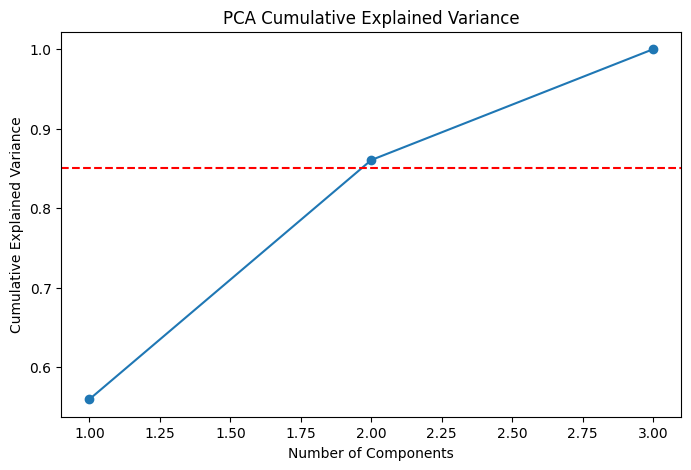

Selected Components Explained Variance: [0.55944298 0.30107891]
Total Variance Retained: 0.8605218940398778


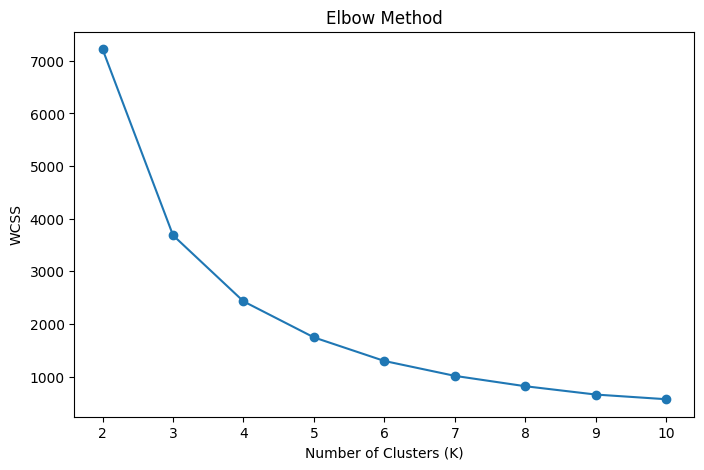

K = 2, Silhouette Score = 0.8897139274951118
K = 3, Silhouette Score = 0.6120712177114285
K = 4, Silhouette Score = 0.6356680440476769
K = 5, Silhouette Score = 0.598704409860102
K = 6, Silhouette Score = 0.5397293659279538
K = 7, Silhouette Score = 0.4971901127231395
K = 8, Silhouette Score = 0.4976584668781143
K = 9, Silhouette Score = 0.4572651131179482
K = 10, Silhouette Score = 0.4567477418742861
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


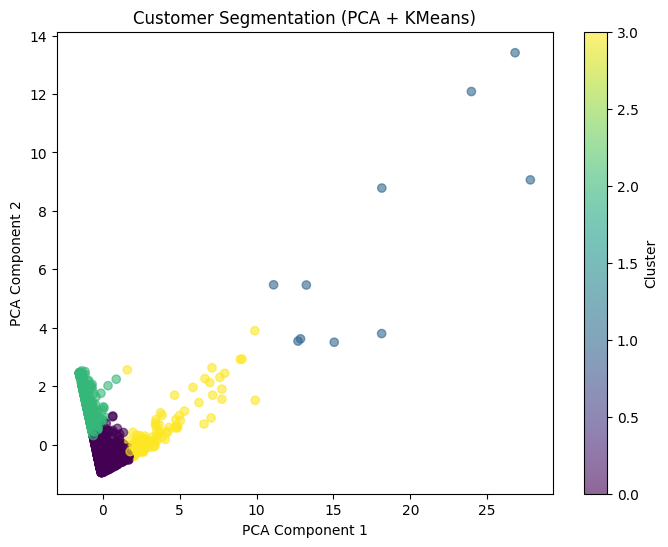

,Recency,Frequency,Monetary
Cluster,,,
0,40.861307,4.650224,1400.232323
1,4.300000,116.300000,127930.999000
2,245.019048,1.808571,480.538125
3,9.007143,32.357143,15413.533000


In [4]:
# Basic Libraries
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Clustering
from sklearn.cluster import KMeans
# Evaluation
from sklearn.metrics import silhouette_score

# ==================== Next Cell ====================

df =pd.read_csv("/content/drive/MyDrive/MachineLearningModels/Unsupervised Learning/data.csv", encoding='latin1')
df.head()

# ==================== Next Cell ====================

df.shape

# ==================== Next Cell ====================

df.isnull().sum()

# ==================== Next Cell ====================

df = df.dropna(subset=['CustomerID'])


# ==================== Next Cell ====================

df.isnull().sum()


# ==================== Next Cell ====================

df = df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


# ==================== Next Cell ====================

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['Quantity','UnitPrice','TotalPrice']].head()


# ==================== Next Cell ====================

# Reference date (last date in dataset)
reference_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()


# ==================== Next Cell ====================

rfm = rfm[rfm['Monetary'] > 0]
rfm.head()


# ==================== Next Cell ====================

rfm.shape


# ==================== Next Cell ====================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]


# ==================== Next Cell ====================

from sklearn.decomposition import PCA

pca_full = PCA()
rfm_pca_full = pca_full.fit_transform(rfm_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance:", cumulative_variance)


# ==================== Next Cell ====================

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.85, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.show()


# ==================== Next Cell ====================

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

print("Selected Components Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))


# ==================== Next Cell ====================

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    kmeans.fit(rfm_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


# ==================== Next Cell ====================

from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    labels = kmeans.fit_predict(rfm_pca)
    score = silhouette_score(rfm_pca, labels)
    print(f"K = {k}, Silhouette Score = {score}")


# ==================== Next Cell ====================

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(rfm_pca)

rfm['Cluster'] = clusters

rfm.head()



# ==================== Next Cell ====================

from google.colab import drive
drive.mount('/content/drive')


# ==================== Next Cell ====================

plt.figure(figsize=(8,6))

plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=clusters,
    cmap='viridis',
    alpha=0.6
)

plt.title("Customer Segmentation (PCA + KMeans)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


# ==================== Next Cell ====================

rfm.groupby('Cluster').mean()


# ==================== Next Cell ====================

